# Using Linear Regression to Predict Aerodynamic Noise from NASA Airfoil Tests

In this notebook, we use linear regression to predict the sound levels of airfoils designed by NASA using their physical measurements as predictor variables. The [Airfoil Self-Noise dataset](https://archive.ics.uci.edu/dataset/291/airfoil+self+noise) comes from UC Irvine's Machine Learning Repository.

During the design of aircraft wings, wind turbine blades, and helicopter rotors, engineers need to predict how much noise a given airfoil geometry will produce at a given airspeed. Airfoils are cross-sections of bodies like wings that are designed to help aircraft fly by splitting airflow to maximize lift and minimize drag. This dataset comes from a series of NASA wind tunnel experiments on NACA 0012 airfoils.

In each experiment, engineers varied four physical parameters and measured the resulting sound pressure level (in decibels). The dataset contains 1,503 measurements with 5 inputs and one continuous output.

The goal here is to train a Linear Regression model to predict the sound levels of the airfoils from the different features.

**Features:**
| **Feature** | **Type** | **Description** | **Units** |
|---|---|---|---|
| Frequency | Integer | Test frequency | Hz |
| AttackAngle | Binary | Angle of attack | degrees |
| ChordLength | Continuous | Chord length of the airfoil | m |
| FreeStreamVelocity | Continuous | Free-stream wind tunnel velocity | m/s |
| SuctionThickness | Continuous | Suction side displacement thickness | m |

**Target:** ScaledSoundPressure — scaled sound pressure level (dB, continuous real-valued)



## Load and Explore Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_package import (
    LinearRegression, 
    StandardScaler, 
    train_test_split,
    regression_metrics
)

np.random.seed(42)

In [24]:
df = pd.read_csv("airfoil_self_noise.dat", sep='\s+', header = None)

# Rename columns
df.columns = [
    "Frequency",
    "Angle_of_Attack",
    "Chord_Length",
    "Free_Stream_Velocity",
    "Suction_Side_Displacement_Thickness",
    "Scaled_Sound_Pressure"
]

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Owinf\AppData\Local\Temp\ipykernel_7488\2840210284.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("airfoil_self_noise.dat", sep='\s+', header = None)


,Frequency,Angle_of_Attack,Chord_Length,Free_Stream_Velocity,Suction_Side_Displacement_Thickness,Scaled_Sound_Pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [25]:
# Assign features and target
X = df.drop(columns=['Scaled_Sound_Pressure'])
y = df["Scaled_Sound_Pressure"]

# Descriptive statistics
print(f"\nTarget (Sound Pressure)  —  mean: {y.mean():.2f}, std: {y.std():.2f}, range: [{y.min()}, {y.max()}]")
X.describe().round(3)


Target (Sound Pressure)  —  mean: 124.84, std: 6.90, range: [103.38, 140.987]


,Frequency,Angle_of_Attack,Chord_Length,Free_Stream_Velocity,Suction_Side_Displacement_Thickness
count,1503.000,1503.000,1503.000,1503.000,1503.000
mean,2886.381,6.782,0.137,50.861,0.011
std,3152.573,5.918,0.094,15.573,0.013
min,200.000,0.000,0.025,31.700,0.000
25%,800.000,2.000,0.051,39.600,0.003
50%,1600.000,5.400,0.102,39.600,0.005
75%,4000.000,9.900,0.229,71.300,0.016
max,20000.000,22.200,0.305,71.300,0.058


---

Below, we createa heatmap displaying the correlations between features.

---

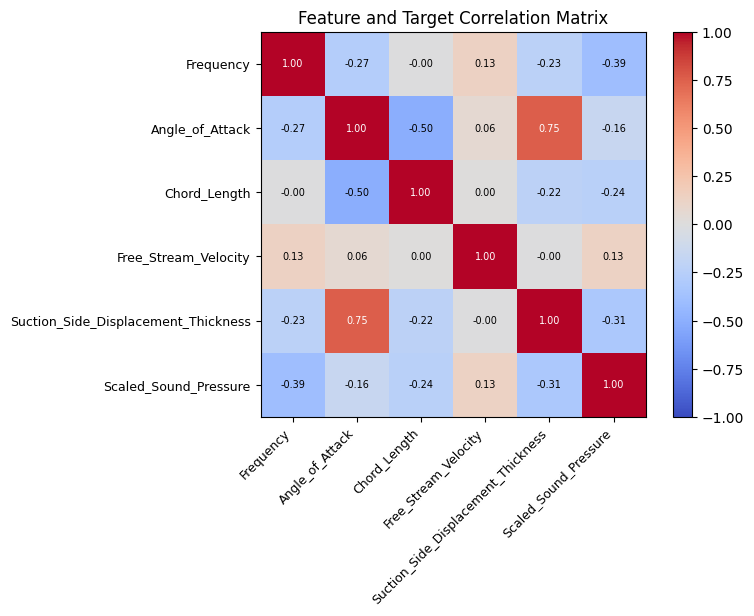


Correlation with Sound Pressure (dB):
Frequency                             -0.391
Suction_Side_Displacement_Thickness   -0.313
Chord_Length                          -0.236
Angle_of_Attack                       -0.156
Free_Stream_Velocity                   0.125


In [26]:
# Correlation heat map (features + target)
X_with_target = X.copy()
X_with_target["Scaled_Sound_Pressure"] = y
corr = X_with_target.corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i,j]) > 0.6 else "black")
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("Feature and Target Correlation Matrix")
plt.show()

print("\nCorrelation with Sound Pressure (dB):")
print(corr["Scaled_Sound_Pressure"].drop("Scaled_Sound_Pressure").sort_values().round(3).to_string())


---

The correlation matrix with annotated values reveals that the five features are largely uncorrelated with each other (most pairwise r values are below 0.2), other than Angle of Attack and Suction Side Displacement Thickness, which show a fairly strong positive correlation (0.75). This is a good sign for linear regression, as multicollinearity would inflate variance in the coefficient estimates.

---

## Data Preprocessing


span very different scales (e.g. Frequency goes up to 20,000 Hz while ChordLength is less than 0.3 m). Thus, we use `StandardScaler` here so gradient descent converges smoothly. Standardization is important for gradient-descent-based linear regression because it ensures all features have comparable gradient magnitudes, preventing a single large-scale feature from dominating the weight updates.

---

In [28]:
X_arr = X.values.astype(float)
X_train, X_test, y_train, y_test = train_test_split(X_arr, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

Train: 1202 samples  |  Test: 301 samples


## Train the Linear Regression Model

Next, we train the linear regression model on the scaled feature data, setting the learning rate equal to 0.05 and the number of epochs equal to 3000. At each epoch, the model computes predictions by multiplying the weights and inputs, then adding the bias. The model then calculates MSE loss and updates the weights according to the computed gradient. We run 3,000 epochs to ensure the loss curve has fully flattened before evaluation.

---

In [29]:
# Define and train the linear regression model

model = LinearRegression()
model.train(X_train_s, y_train, eta=0.05, epochs=3000)
print(f"Final training MSE: {model.losses[-1]:.4f}")


Final training MSE: 22.8556


---

The graph below plots the MSE losses against the epoch number. The curve shows a steep descent in the first hundred or so epochs followed by a flattening plateau, indicating convergence.

---

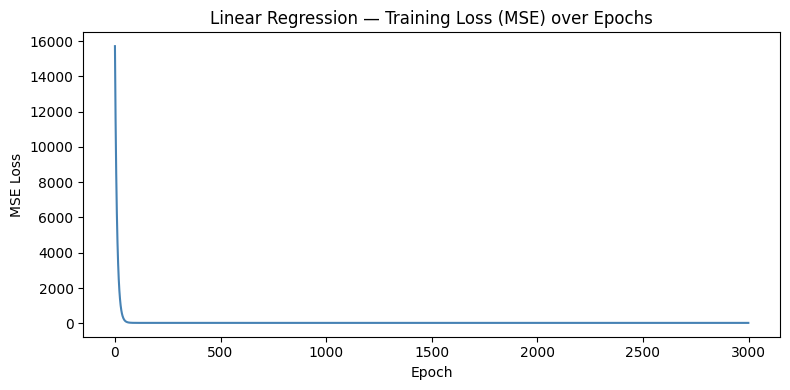

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(model.losses, color="steelblue", linewidth=1.5)
plt.title("Linear Regression — Training Loss (MSE) over Epochs", fontsize=12)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.tight_layout()
plt.show()


## Evaluation

Now that we have trained our model, it's time to evaluate it's performance on the test set. For informational purposes (not neccessarily required in practice), we use the full suite of evaluation methods included in the `LinearRegression` class.

---

In [36]:
y_pred_train = model.predict(X_train_s)
y_pred_test  = model.predict(X_test_s)

n_features = X_train_s.shape[1]

print(f"  RMSE         : {regression_metrics.rmse(y_test, y_pred_test):.4f} dB")
print(f"  MAE          : {regression_metrics.mae(y_test, y_pred_test):.4f} dB")
print(f"  MAPE         : {regression_metrics.mape(y_test, y_pred_test):.2f} %")
print(f"  SMAPE        : {regression_metrics.smape(y_test, y_pred_test):.2f} %")
print(f"  R²           : {regression_metrics.r_squared(y_test, y_pred_test):.4f}")
print(f"  Adjusted R²  : {regression_metrics.adjusted_r_squared(y_test, y_pred_test, n_features):.4f}")
print(f"  AIC          : {regression_metrics.aic(y_test, y_pred_test, n_features+1):.2f}")
print(f"  BIC          : {regression_metrics.bic(y_test, y_pred_test, n_features+1):.2f}")

  RMSE         : 4.8916 dB
  MAE          : 3.7791 dB
  MAPE         : 3.02 %
  SMAPE        : 3.02 %
  R²           : 0.4985
  Adjusted R²  : 0.4900
  AIC          : 967.69
  BIC          : 989.93


---

Our model returns an R-squared value of 0.50, which implies that 50% of the total variation in the sound pressure can be explained by the linear model. This is a meaningful but far from complete description of the physical relationship. A plot of the data with both the fitted regression and the true unknown regression line is shown below.

---

C:\Users\Owinf\AppData\Local\Temp\ipykernel_7488\2306001315.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x_range, x_range, "r--", alpha=0.5, label="Perfect Fit (y=x)", color = "blue")


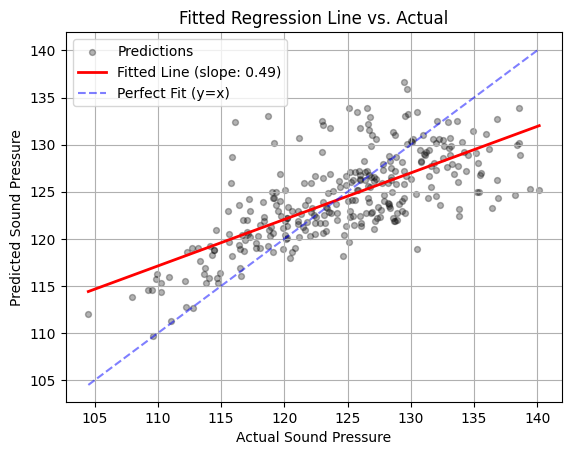

In [ ]:
# Scatter plot of the data
plt.scatter(y_test, y_pred_test, alpha=0.3, s=18, color="black", label="Predictions")

# Calculate the fitted regression line (y = mx + b)
m, b = np.polyfit(y_test, y_pred_test, 1)
x_range = np.array([y_test.min(), y_test.max()])
plt.plot(x_range, m * x_range + b, color="red", linewidth=2, label=f"Fitted Line (slope: {m:.2f})")

# Plot the true unknown regression line as a referebce
plt.plot(x_range, x_range, "r--", alpha=0.5, label="Perfect Fit (y=x)", color = "blue")

# Formatting
plt.title("Fitted Regression Line vs. Actual", fontsize=12)
plt.xlabel("Actual Sound Pressure")
plt.ylabel("Predicted Sound Pressure")
plt.grid(zorder = 1)
plt.legend()
plt.show()

---

We can also see which features were most important in predicting the sound pressure. Because we standardized the features, the model weights are directly comparable — the larger absolute weight, the more influence on the predicted sound pressure.We print weights sorted by absolute magnitude and also visualise them as a bar chart coloured by sign (blue for positive, orange for negative).

---

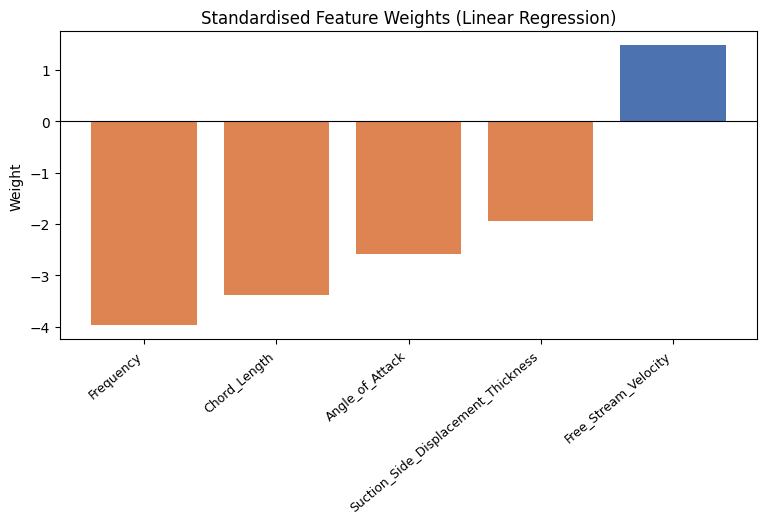

In [38]:
feat_names = list(X.columns)
weights = model.weights

order = np.argsort(np.abs(weights))[::-1]
colors = ["#4C72B0" if w > 0 else "#DD8452" for w in weights[order]]

plt.figure(figsize=(9, 4))
plt.bar(range(len(feat_names)), weights[order], color=colors)
plt.xticks(range(len(feat_names)), [feat_names[i] for i in order], rotation=40, ha="right", fontsize=9)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Standardised Feature Weights (Linear Regression)")
plt.ylabel("Weight")
plt.show()


---

From this graph, we can see that Frequency and Chord Length had the highest absolute weights.

Overall, this dataset serves as an ideal demonstration that linear regression is a strong, interpretable baseline even when it cannot achieve substantially high accuracy.

---